# Anchor-point regression — core workflow (Part 1 of 2)

Factors are **observable cube moves** at a small fixed set of
`(expiry, tenor)` anchor cells (typically the liquid swaption /
swap points). Every other cell's daily diff is OLS / ridge
regressed onto the anchor moves, so the beta panel is the
executable hedge: a move at anchor *a* of size 1 implies a move of
`betas[cell, a]` at every other cell, by construction.

Unlike the PCA family (vanilla / varimax / block / sparse /
constrained / separable), the factors here are not latent — they
are real tradeable instruments picked up front. That makes the
hedge directly executable and the beta panel immediately
interpretable to a trader, at the cost of variance-retained
(observable cells are not optimal in the PCA sense).

This notebook walks the `factors.anchor` API end-to-end on the
**rate** surface (the most natural use case — anchor points are
tradeable swap tenors). The liquid anchor universe is fixed by
convention to the desk-quotable cells:

* **expiry**: 1M, 3M, 6M, 1Y, 2Y, 3Y, 5Y, 10Y, 15Y, 20Y
* **tenor**:  1Y, 2Y, 5Y, 10Y, 30Y

= **50** candidate anchor cells out of the **204** cube cells. The
non-liquid cells (e.g. 9M expiry, 7Y tenor) are *targets* — they
must be hedged through the liquid anchors, never picked as anchors
themselves.

The last section sketches several alternative anchor-selection
criteria beyond the variance-greedy default in
`greedy_anchor_select`.

## 0. Setup and data

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from config import EXPIRY_LABELS, TENOR_LABELS, EXPIRY_RANK, TENOR_RANK
from pca import load_long, to_wide
from factors import (
    fit_ridge, fit_ridge_rolling,
    get_anchor_slice, residual_panel,
    anchor_diagnostics, greedy_anchor_select,
    r2_heatmap, beta_stability, anchor_metrics_row,
)

sns.set_theme(style="whitegrid")

rate = to_wide(load_long("../data/mock/rate.pkl")).diff().dropna()
print("rate diff:", rate.shape, f"({rate.shape[0]} days x {rate.shape[1]} cells)")

rate diff: (499, 204) (499 days x 204 cells)


## 1. Liquid anchor universe

The set of cells the desk can actually trade. Everything outside
this set is a hedge target only.

liquid universe: 50 cells
forbidden cells: 154 (targets only)
total cube:      204 cells


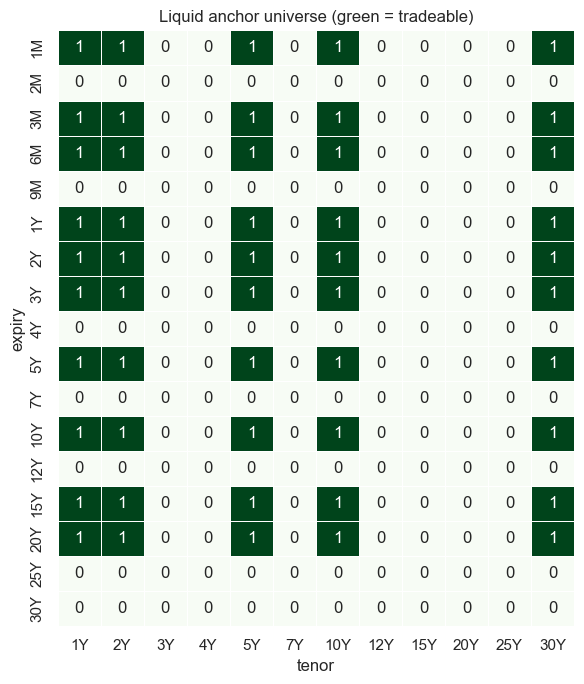

In [2]:
LIQUID_EXPIRIES = ["1M", "3M", "6M", "1Y", "2Y", "3Y", "5Y", "10Y", "15Y", "20Y"]
LIQUID_TENORS   = ["1Y", "2Y", "5Y", "10Y", "30Y"]

LIQUID_UNIVERSE = [(e, t) for e in LIQUID_EXPIRIES for t in LIQUID_TENORS]
LIQUID_SET = set(LIQUID_UNIVERSE)

# Cells outside the liquid universe are forbidden anchors — pass to
# greedy_anchor_select as `exclude`.
FORBIDDEN = [c for c in rate.columns if c not in LIQUID_SET]

print(f"liquid universe: {len(LIQUID_UNIVERSE)} cells")
print(f"forbidden cells: {len(FORBIDDEN)} (targets only)")
print(f"total cube:      {rate.shape[1]} cells")

# Visualise the liquid mask on the cube.
mask = pd.DataFrame(0.0, index=EXPIRY_LABELS, columns=TENOR_LABELS)
for (e, t) in LIQUID_UNIVERSE:
    mask.loc[e, t] = 1.0
fig, ax = plt.subplots(figsize=(6, 7))
sns.heatmap(mask, ax=ax, cmap="Greens", cbar=False,
            linewidths=0.5, linecolor="white", annot=True, fmt=".0f")
ax.set_title("Liquid anchor universe (green = tradeable)")
ax.set_xlabel("tenor"); ax.set_ylabel("expiry")
fig.tight_layout()

## 2. Hand-chosen baseline anchors

A trader's first guess would typically be a short × short, a mid ×
mid, and a long × long anchor — sketch the principal diagonal of
the cube. We start there and benchmark every other selection
method against this human-readable baseline.

In [3]:
BASELINE_ANCHORS = [
    ("3M",  "2Y"),    # short expiry, short tenor
    ("2Y",  "10Y"),   # mid   expiry, mid   tenor
    ("10Y", "30Y"),   # long  expiry, long  tenor
]
assert all(a in LIQUID_SET for a in BASELINE_ANCHORS), "baseline must be liquid"
print("baseline anchors:", BASELINE_ANCHORS)

baseline anchors: [('3M', '2Y'), ('2Y', '10Y'), ('10Y', '30Y')]


## 3. `fit_ridge` and `r2_heatmap`

Fit the beta panel for the baseline anchors and visualise per-cell
in-sample R². Anchor cells score exactly 1 by construction
(one-hot beta); off-anchor cells show how much variance the anchors
explain there.

In [4]:
betas_base = fit_ridge(rate, BASELINE_ANCHORS, lam=0.0)
print("betas shape:", betas_base.shape, "  (n_cells x n_anchors)")
print("\nanchor cells (one-hot rows):")
print(betas_base.loc[BASELINE_ANCHORS].round(3))
print("\nmean |beta| per anchor:")
print(betas_base.abs().mean().round(3))

r2_base = r2_heatmap(rate, BASELINE_ANCHORS, lam=0.0)
print(f"\nmean per-cell R²: {r2_base.values.mean():.4f}")
print(f"min  per-cell R²: {r2_base.values.min():.4f}  (worst-explained cell)")

betas shape: (204, 3)   (n_cells x n_anchors)

anchor cells (one-hot rows):
              3M|2Y  2Y|10Y  10Y|30Y
expiry tenor                        
3M     2Y       1.0     0.0      0.0
2Y     10Y      0.0     1.0      0.0
10Y    30Y      0.0     0.0      1.0

mean |beta| per anchor:
3M|2Y      0.051
2Y|10Y     0.054
10Y|30Y    0.049
dtype: float64

mean per-cell R²: 0.0259
min  per-cell R²: 0.0003  (worst-explained cell)


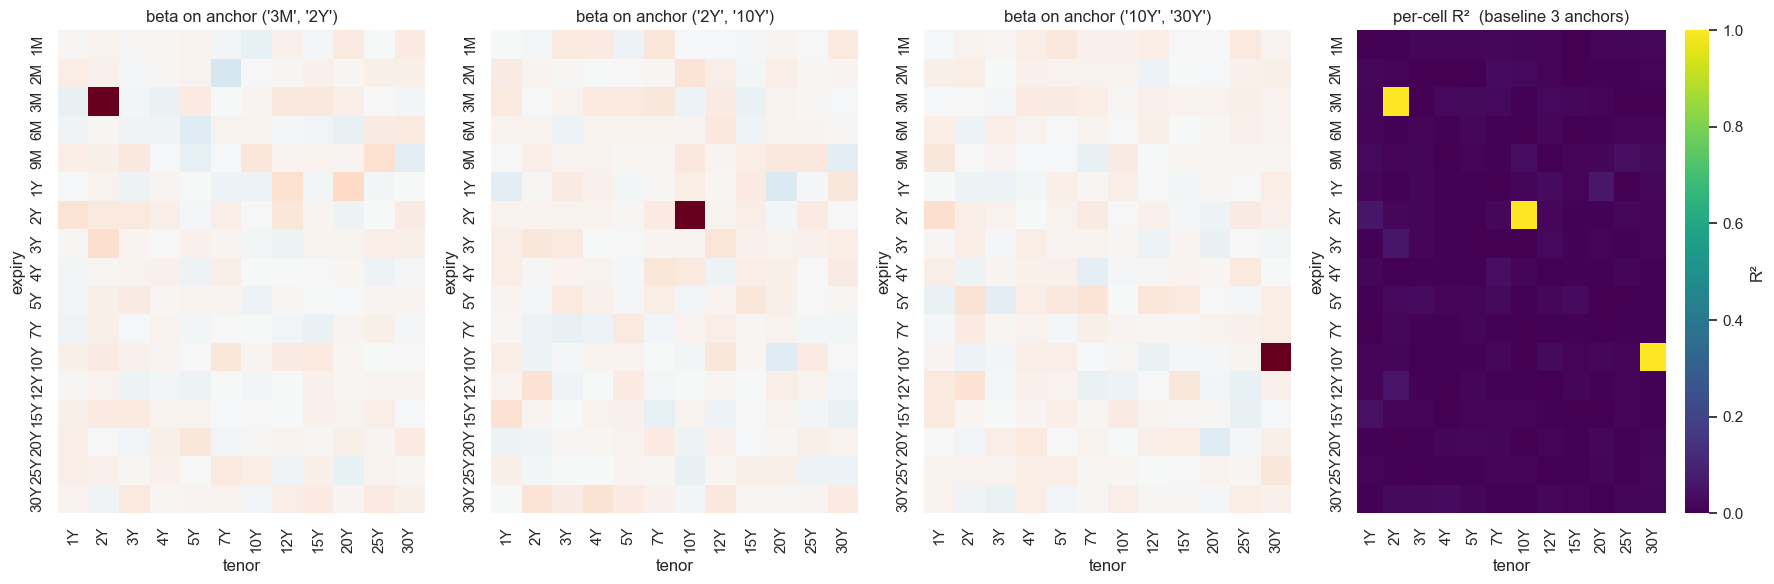

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6),
                         gridspec_kw={"width_ratios": [1, 1, 1, 1.05]})
# One beta heatmap per anchor + the R² heatmap.
for i, anchor in enumerate(BASELINE_ANCHORS):
    col = f"{anchor[0]}|{anchor[1]}"
    grid = betas_base[col].unstack(level="tenor")
    grid = grid.reindex(
        index=[e for e in EXPIRY_LABELS if e in grid.index],
        columns=[t for t in TENOR_LABELS if t in grid.columns],
    )
    vmax = float(grid.abs().max().max())
    sns.heatmap(grid, ax=axes[i], cmap="RdBu_r", center=0,
                vmin=-vmax, vmax=vmax, cbar=False)
    axes[i].set_title(f"beta on anchor {anchor}")
    axes[i].set_xlabel("tenor"); axes[i].set_ylabel("expiry")
sns.heatmap(r2_base, ax=axes[3], cmap="viridis", vmin=0, vmax=1,
            cbar_kws={"label": "R²"})
axes[3].set_title("per-cell R²  (baseline 3 anchors)")
axes[3].set_xlabel("tenor"); axes[3].set_ylabel("expiry")
fig.tight_layout()

**Reading the panels.** Each beta heatmap shows the hedge ratio of
every cube cell to one anchor — bands where one colour dominates
tell you which region of the cube tracks that anchor. The R²
heatmap shows where the three-anchor model leaves residual: dark
patches are cells that don't move with any of the chosen anchors
and need either more anchors or a different selection.

## 4. `anchor_diagnostics` — multicollinearity

Correlation matrix, Gram condition number, and VIFs for the
baseline anchors. Condition number >~30 or VIF >~10 means the
anchor set is redundant — either drop one or use `lam>0` in
`fit_ridge`.

condition number: 1.20

VIFs:
3M|2Y      1.01
2Y|10Y     1.00
10Y|30Y    1.00
Name: vif, dtype: float64

correlation matrix:
         3M|2Y  2Y|10Y  10Y|30Y
3M|2Y    1.000   0.063   -0.032
2Y|10Y   0.063   1.000   -0.005
10Y|30Y -0.032  -0.005    1.000


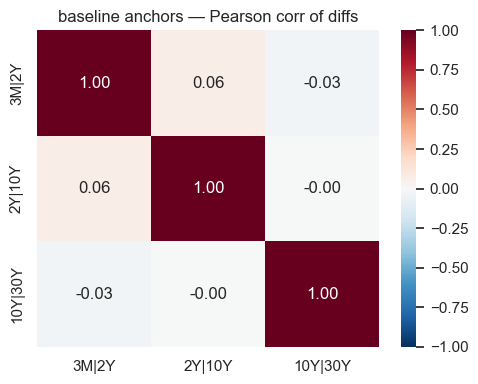

In [6]:
diag = anchor_diagnostics(rate, BASELINE_ANCHORS)
print(f"condition number: {diag['condition_number']:.2f}")
print("\nVIFs:")
print(diag["vif"].round(2))
print("\ncorrelation matrix:")
print(diag["corr"].round(3))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(diag["corr"], ax=ax, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f")
ax.set_title("baseline anchors — Pearson corr of diffs")
fig.tight_layout()

## 5. `fit_ridge_rolling` and `beta_stability`

Refit on rolling 126-day windows (strict past, no leakage). The
std of each `(cell, anchor)` rolling beta over time tells us where
the hedge ratio drifts and where it's nailed down.

rolling betas: (373, 612) (n_dates x n_cells*n_anchors)

std panel: (204, 3)
mean std per anchor:
anchor
10Y|30Y    0.0852
2Y|10Y     0.0835
3M|2Y      0.0848
dtype: float64


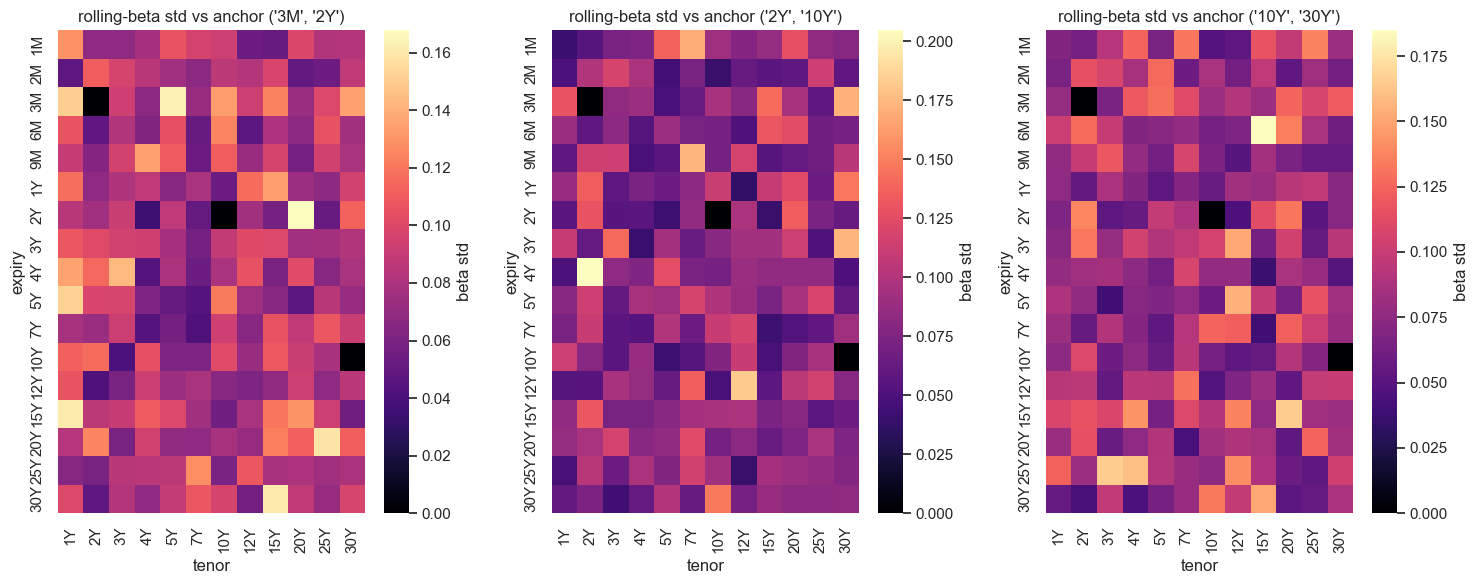

In [7]:
rolling = fit_ridge_rolling(rate, BASELINE_ANCHORS, lam=0.0, window=126)
print(f"rolling betas: {rolling.shape} (n_dates x n_cells*n_anchors)")

std_panel = beta_stability(rolling, BASELINE_ANCHORS)
print(f"\nstd panel: {std_panel.shape}")
print(f"mean std per anchor:\n{std_panel.mean().round(4)}")

# Per-anchor std heatmap on the cube grid.
fig, axes = plt.subplots(1, len(BASELINE_ANCHORS), figsize=(15, 6))
for i, anchor in enumerate(BASELINE_ANCHORS):
    col = f"{anchor[0]}|{anchor[1]}"
    grid = std_panel[col].unstack(level="tenor")
    grid = grid.reindex(
        index=[e for e in EXPIRY_LABELS if e in grid.index],
        columns=[t for t in TENOR_LABELS if t in grid.columns],
    )
    sns.heatmap(grid, ax=axes[i], cmap="magma",
                cbar_kws={"label": "beta std"})
    axes[i].set_title(f"rolling-beta std vs anchor {anchor}")
    axes[i].set_xlabel("tenor"); axes[i].set_ylabel("expiry")
fig.tight_layout()

Bright cells in any of the three heatmaps are the ones whose hedge
ratio drifts the most — useful as a flag for cells where a static
beta will mis-hedge.

## 6. `anchor_metrics_row` — single-row summary

The same shape as `factors.metrics_table` rows so the anchor track
slots straight into the cross-method comparison sheet.

In [8]:
row_base = anchor_metrics_row(
    rate, BASELINE_ANCHORS, lam=0.0, window=126,
)
pd.DataFrame([row_base]).round(4)

,method,variance_retained,loading_sparsity_gini,rolling_stability,hedge_residual_r2,r2_ridge_mean,r2_nnls_mean,r2_simplex_mean,hull_breach_pct
0,anchor_ridge_k3_lam0.0,0.0259,0.4627,0.0,0.9741,0.0259,0.0237,-0.2831,1.0


## 7. Greedy forward selection on the liquid universe

`greedy_anchor_select` with `exclude=FORBIDDEN` restricts the
search to liquid cells only. Each step picks the cell maximising
cumulative R² across the full cube (including illiquid targets).
We sweep `k=1..7` and watch where the marginal R² curve flattens.

In [9]:
K_MAX = 7
greedy_history = greedy_anchor_select(
    rate, k=K_MAX, lam=1e-4, exclude=FORBIDDEN,
)
greedy_df = pd.DataFrame(greedy_history)
greedy_df.index = range(1, len(greedy_df) + 1)
greedy_df.index.name = "step"
greedy_df.round(4)

greedy step 1/7: picked ('1Y', '2Y'), cumulative R² = 0.0105, marginal R² = 0.0105


greedy step 2/7: picked ('20Y', '30Y'), cumulative R² = 0.0205, marginal R² = 0.0100


greedy step 3/7: picked ('2Y', '10Y'), cumulative R² = 0.0302, marginal R² = 0.0097


greedy step 4/7: picked ('10Y', '2Y'), cumulative R² = 0.0397, marginal R² = 0.0095


greedy step 5/7: picked ('5Y', '2Y'), cumulative R² = 0.0485, marginal R² = 0.0088


greedy step 6/7: picked ('15Y', '1Y'), cumulative R² = 0.0573, marginal R² = 0.0088


greedy step 7/7: picked ('2Y', '30Y'), cumulative R² = 0.0660, marginal R² = 0.0088


,anchor,marginal_r2,cumulative_r2
step,,,
1,"(1Y, 2Y)",0.0105,0.0105
2,"(20Y, 30Y)",0.0100,0.0205
3,"(2Y, 10Y)",0.0097,0.0302
4,"(10Y, 2Y)",0.0095,0.0397
5,"(5Y, 2Y)",0.0088,0.0485
6,"(15Y, 1Y)",0.0088,0.0573
7,"(2Y, 30Y)",0.0088,0.0660


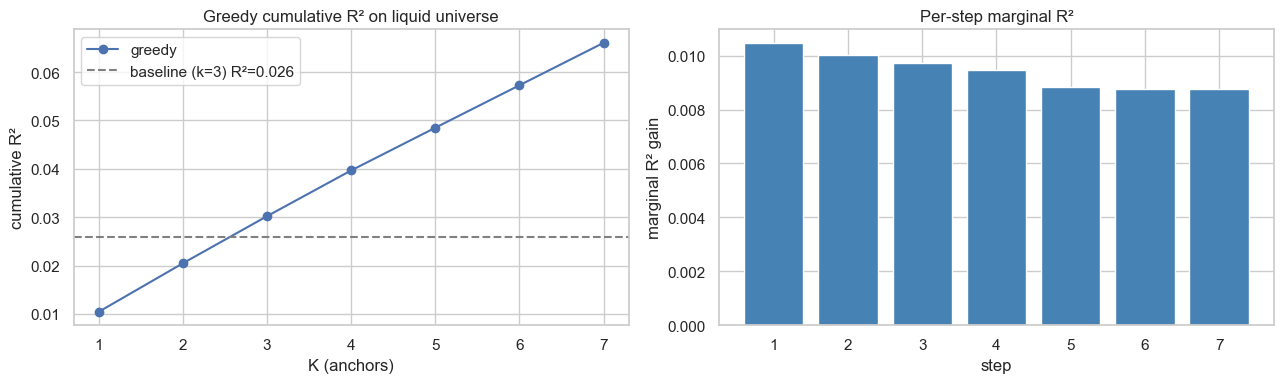

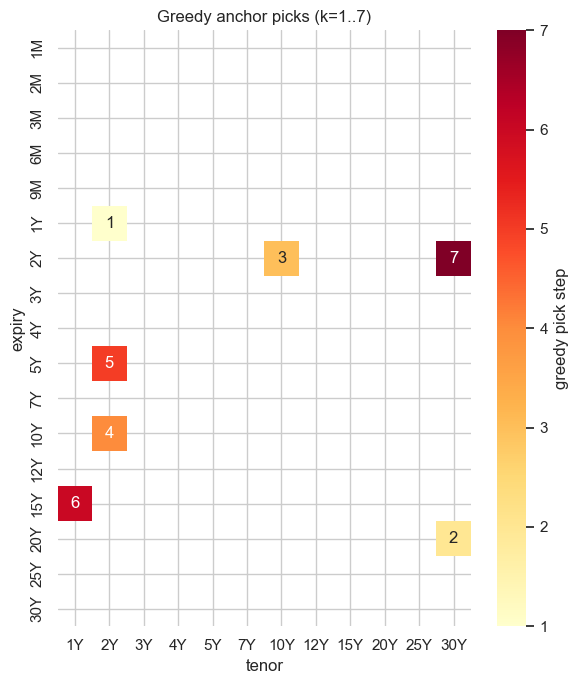

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(greedy_df.index, greedy_df["cumulative_r2"],
             marker="o", label="greedy")
axes[0].axhline(row_base["variance_retained"], color="grey",
                linestyle="--", label=f"baseline (k=3) R²={row_base['variance_retained']:.3f}")
axes[0].set_xlabel("K (anchors)"); axes[0].set_ylabel("cumulative R²")
axes[0].set_title("Greedy cumulative R² on liquid universe")
axes[0].legend()
axes[1].bar(greedy_df.index, greedy_df["marginal_r2"], color="steelblue")
axes[1].set_xlabel("step"); axes[1].set_ylabel("marginal R² gain")
axes[1].set_title("Per-step marginal R²")
fig.tight_layout()

# Show which cells got picked, by step.
pick_grid = pd.DataFrame(np.nan, index=EXPIRY_LABELS, columns=TENOR_LABELS)
for step, row in enumerate(greedy_history, start=1):
    e, t = row["anchor"]
    pick_grid.loc[e, t] = step
fig, ax = plt.subplots(figsize=(6, 7))
sns.heatmap(pick_grid, ax=ax, cmap="YlOrRd", annot=True, fmt=".0f",
            cbar_kws={"label": "greedy pick step"})
ax.set_title(f"Greedy anchor picks (k=1..{K_MAX})")
ax.set_xlabel("tenor"); ax.set_ylabel("expiry")
fig.tight_layout()

## 8. Baseline vs greedy at matched K

Drop the human baseline (k=3) into the same metric row as the
greedy-k3 anchors. R² heatmaps side-by-side reveal where greedy
saves residual variance.

In [11]:
greedy_k3 = [h["anchor"] for h in greedy_history[:3]]
greedy_k5 = [h["anchor"] for h in greedy_history[:5]]

rows = []
for name, anchors in [("baseline_k3_hand", BASELINE_ANCHORS),
                      ("greedy_k3",         greedy_k3),
                      ("greedy_k5",         greedy_k5)]:
    row = anchor_metrics_row(rate, anchors, lam=1e-4, window=126)
    row["label"] = name
    row["anchors"] = anchors
    rows.append(row)
compare = pd.DataFrame(rows).set_index("label")
compare.round(4)

,method,variance_retained,loading_sparsity_gini,rolling_stability,hedge_residual_r2,r2_ridge_mean,r2_nnls_mean,r2_simplex_mean,hull_breach_pct,anchors
label,,,,,,,,,,
baseline_k3_hand,anchor_ridge_k3_lam0.0001,0.0259,0.4627,0.0,0.9741,0.0259,0.0237,-0.2831,1.0,"[(3M, 2Y), (2Y, 10Y), (10Y, 30Y)]"
greedy_k3,anchor_ridge_k3_lam0.0001,0.0291,0.4486,0.0,0.9709,0.0291,0.0275,-0.2582,1.0,"[(1Y, 2Y), (20Y, 30Y), (2Y, 10Y)]"
greedy_k5,anchor_ridge_k5_lam0.0001,0.0466,0.4598,0.0,0.9534,0.0466,0.0439,-0.1078,1.0,"[(1Y, 2Y), (20Y, 30Y), (2Y, 10Y), (10Y, 2Y), (..."


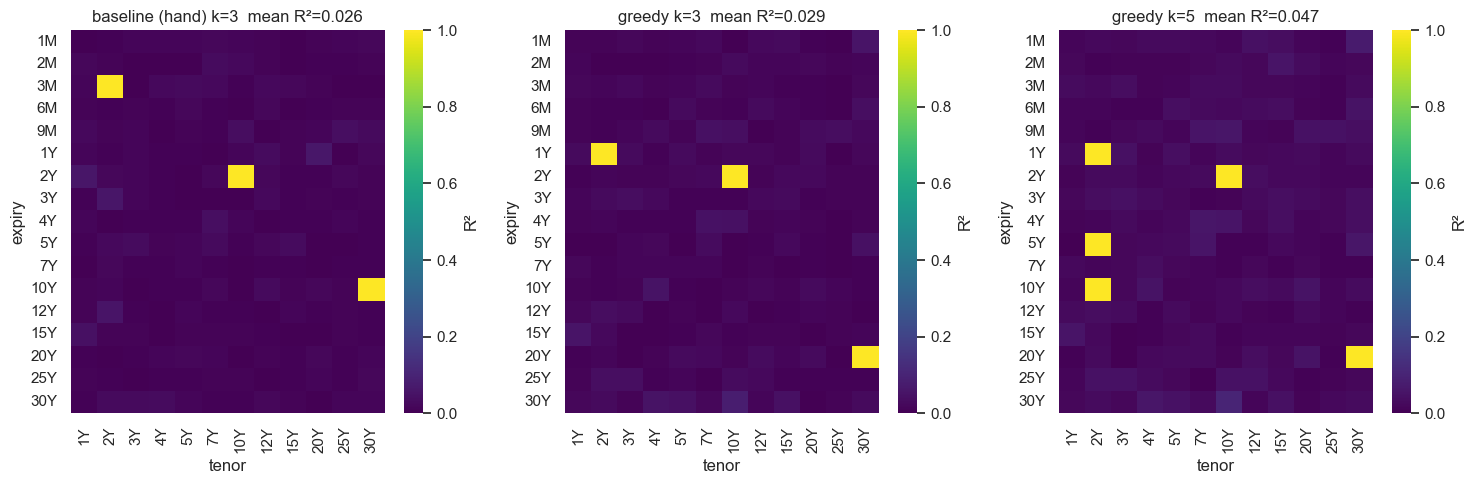

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, anchors) in zip(
    axes,
    [("baseline (hand) k=3", BASELINE_ANCHORS),
     ("greedy k=3",          greedy_k3),
     ("greedy k=5",          greedy_k5)],
):
    hm = r2_heatmap(rate, anchors, lam=1e-4)
    sns.heatmap(hm, ax=ax, cmap="viridis", vmin=0, vmax=1,
                cbar_kws={"label": "R²"})
    ax.set_title(f"{name}  mean R²={hm.values.mean():.3f}")
    ax.set_xlabel("tenor"); ax.set_ylabel("expiry")
fig.tight_layout()

## 9. Alternative anchor-selection methods

Forward greedy on cumulative R² is one criterion among many.
Sketches below — pick whichever criterion matches the desk's
actual constraint (liquidity, hedge stability, interpretability).

### Proposed methods

| method | criterion | implemented below |
|---|---|---|
| **Random baseline** | uniform random K-subsets; report the R² distribution as a sanity check for greedy | yes |
| **Spatial uniform** | K cells uniformly spaced on the (expiry, tenor) grid — data-agnostic, simplest possible | yes |
| **Cluster-centroid** | k-means on cell time series; pick the cell closest to each centroid — natural data-driven partition | yes |
| **Diversity-aware greedy** | greedy on R² minus a penalty for high `\|corr\|` with already-selected anchors — discourages collinear picks | yes |
| **Backward elimination** | start with all 50 liquid cells, drop the cell with the smallest R² hit until K remain — slower, can find sets greedy misses | sketch only |
| **Conditioning-aware greedy** | greedy + reject any candidate that pushes condition number above a threshold — guarantees a well-posed OLS without ridge | sketch only |
| **Leverage scores from top-k PCA** | use the top-k PCA loadings as importance scores; pick the K liquid cells with the largest sum of squared loadings — bridges PCA and anchor-regression | sketch only |
| **MIP optimum** | exact integer-programming solution to the K-of-N variance-retained problem — gold standard but O(N choose K), only for small grids | sketch only |

The four implemented methods compare directly against greedy below.

In [13]:
def _r2(anchors, lam=1e-4):
    """Mean per-cell R² for a candidate anchor set."""
    try:
        betas = fit_ridge(rate, anchors, lam=lam)
        am = get_anchor_slice(rate, anchors)
        resid = residual_panel(rate, am, betas)
        aligned = rate.loc[resid.index, resid.columns]
        ss_r = (resid ** 2).sum(axis=0)
        ss_t = ((aligned - aligned.mean()) ** 2).sum(axis=0)
        return float((1.0 - ss_r / ss_t.where(ss_t > 0, 1.0)).mean())
    except (ValueError, np.linalg.LinAlgError):
        return float("nan")


def random_baseline(k, n_trials=200, seed=0):
    """Distribution of R² across n_trials random K-subsets of LIQUID_UNIVERSE."""
    rng = np.random.default_rng(seed)
    r2s = []
    for _ in range(n_trials):
        idx = rng.choice(len(LIQUID_UNIVERSE), size=k, replace=False)
        anchors = [LIQUID_UNIVERSE[i] for i in idx]
        r2 = _r2(anchors)
        if np.isfinite(r2):
            r2s.append(r2)
    return pd.Series(r2s, name=f"random_r2_k{k}")


def spatial_uniform_anchors(k):
    """K cells spaced uniformly across the liquid (expiry, tenor) grid.
    Greedy farthest-point in (EXPIRY_RANK, TENOR_RANK) coordinates,
    seeded at the geometric centroid of the universe."""
    pts = np.array([(EXPIRY_RANK[e], TENOR_RANK[t])
                    for e, t in LIQUID_UNIVERSE], dtype=float)
    center = pts.mean(axis=0)
    seed_i = int(np.argmin(np.linalg.norm(pts - center, axis=1)))
    picked = [seed_i]
    while len(picked) < k:
        d = np.min(np.linalg.norm(
            pts[:, None, :] - pts[picked][None, :, :], axis=-1
        ), axis=1)
        d[picked] = -1
        picked.append(int(np.argmax(d)))
    return [LIQUID_UNIVERSE[i] for i in picked]


def cluster_centroid_anchors(k, seed=0):
    """K-means on cell time series (each cell = one point in R^T), then
    pick the *liquid* cell whose time series is closest to each cluster
    centroid. Captures the natural correlation clusters of the cube."""
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler
    X = rate.dropna().T.values   # (n_cells, n_days)
    Xs = StandardScaler().fit_transform(X)
    km = KMeans(n_clusters=k, random_state=seed, n_init=10).fit(Xs)
    cells = list(rate.columns)
    liquid_mask = np.array([c in LIQUID_SET for c in cells])
    picks = []
    for c_idx in range(k):
        cen = km.cluster_centers_[c_idx]
        d = np.linalg.norm(Xs - cen, axis=1)
        d[~liquid_mask] = np.inf  # constrain to liquid universe
        picks.append(cells[int(np.argmin(d))])
    # K-means can land two centroids on the same liquid cell — dedupe.
    seen, dedup = set(), []
    for c in picks:
        if c not in seen:
            seen.add(c); dedup.append(c)
    return dedup


def diversity_greedy_select(k, alpha=0.05, lam=1e-4):
    """Forward greedy on `R²(S ∪ {c}) − alpha·max_{a in S}|corr(c, a)|`.
    The penalty term discourages picks that duplicate the information
    already provided by a selected anchor. `alpha=0` collapses back to
    plain greedy."""
    corr_all = rate.corr().abs()
    selected, history = [], []
    prev_r2 = 0.0
    for step in range(k):
        cands = [c for c in LIQUID_UNIVERSE if c not in selected]
        best, best_score, best_r2 = None, -np.inf, 0.0
        for cand in cands:
            r2 = _r2(selected + [cand], lam=lam)
            if not np.isfinite(r2):
                continue
            max_corr = max((corr_all.loc[cand, s] for s in selected),
                           default=0.0)
            score = r2 - alpha * float(max_corr)
            if score > best_score:
                best_score, best_r2, best = score, r2, cand
        if best is None:
            break
        selected.append(best)
        history.append({
            "anchor":        best,
            "marginal_r2":   best_r2 - prev_r2,
            "cumulative_r2": best_r2,
        })
        prev_r2 = best_r2
    return history

In [14]:
K_COMPARE = 5

print("running random baseline (200 trials, may take ~30s)...")
rand_r2 = random_baseline(K_COMPARE, n_trials=200)
print(f"  random R² (k={K_COMPARE}): mean={rand_r2.mean():.4f}, "
      f"p50={rand_r2.median():.4f}, p95={rand_r2.quantile(0.95):.4f}")

spatial = spatial_uniform_anchors(K_COMPARE)
cluster = cluster_centroid_anchors(K_COMPARE)
diversity_hist = diversity_greedy_select(K_COMPARE, alpha=0.05)
diversity = [h["anchor"] for h in diversity_hist]

method_sets = {
    "greedy":             greedy_k5,
    "diversity_greedy":   diversity,
    "spatial_uniform":    spatial,
    "cluster_centroid":   cluster,
    "random_p50":         None,  # placeholder, filled below
}

rows = []
for name, anchors in method_sets.items():
    if name == "random_p50":
        rows.append({
            "method":  "random_k5_p50",
            "variance_retained": float(rand_r2.median()),
            "loading_sparsity_gini": float("nan"),
            "rolling_stability":     float("nan"),
            "hedge_residual_r2":     1.0 - float(rand_r2.median()),
            "anchors": "(distribution)",
            "label":   name,
        })
        continue
    row = anchor_metrics_row(rate, anchors, lam=1e-4, window=126)
    row["anchors"] = anchors
    row["label"]   = name
    rows.append(row)
compare_methods = pd.DataFrame(rows).set_index("label")
compare_methods.round(4)

running random baseline (200 trials, may take ~30s)...


  random R² (k=5): mean=0.0427, p50=0.0427, p95=0.0446


,method,variance_retained,loading_sparsity_gini,rolling_stability,hedge_residual_r2,r2_ridge_mean,r2_nnls_mean,r2_simplex_mean,hull_breach_pct,anchors
label,,,,,,,,,,
greedy,anchor_ridge_k5_lam0.0001,0.0466,0.4598,0.0,0.9534,0.0466,0.0439,-0.1078,1.0,"[(1Y, 2Y), (20Y, 30Y), (2Y, 10Y), (10Y, 2Y), (..."
diversity_greedy,anchor_ridge_k5_lam0.0001,0.0458,0.4532,0.0,0.9542,0.0458,0.0426,-0.1073,1.0,"[(1Y, 2Y), (2Y, 10Y), (5Y, 2Y), (20Y, 30Y), (5..."
spatial_uniform,anchor_ridge_k5_lam0.0001,0.0423,0.4732,0.0,0.9577,0.0423,0.0386,-0.1383,1.0,"[(3Y, 5Y), (1M, 30Y), (20Y, 30Y), (1M, 1Y), (2..."
cluster_centroid,anchor_ridge_k4_lam0.0001,0.0360,0.4539,0.0,0.9640,0.0360,0.0341,-0.1396,1.0,"[(5Y, 10Y), (1M, 2Y), (15Y, 2Y), (3Y, 2Y)]"
random_p50,random_k5_p50,0.0427,NaN,NaN,0.9573,NaN,NaN,NaN,NaN,(distribution)


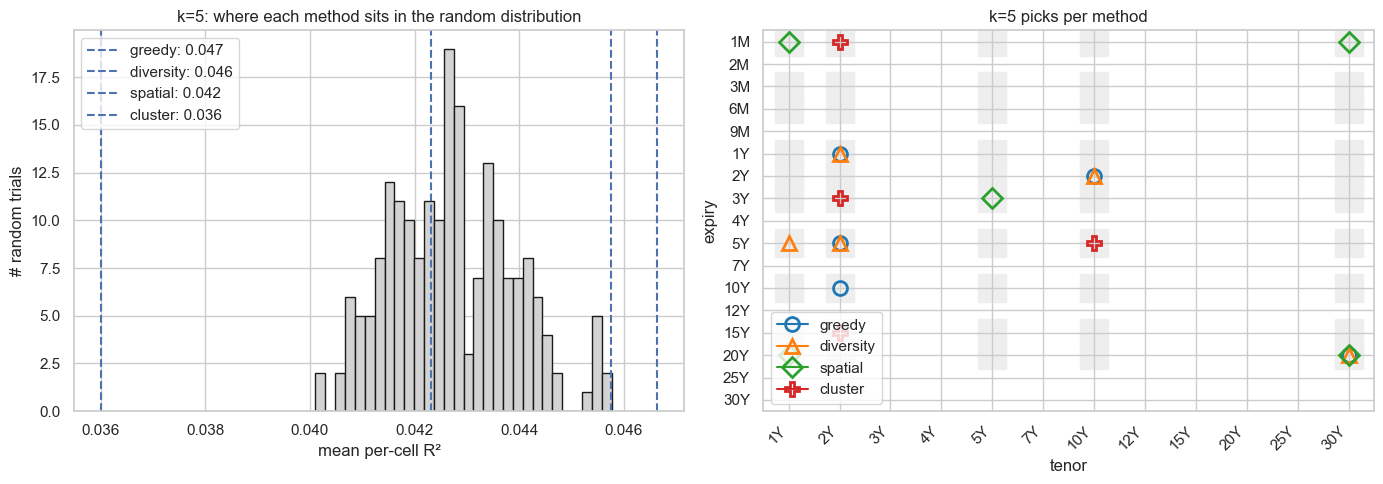

In [15]:
# (a) random-baseline distribution with greedy / diversity / spatial /
#     cluster marked as vertical lines.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(rand_r2, bins=30, color="lightgrey", edgecolor="k")
for name, anchors in [("greedy", greedy_k5), ("diversity", diversity),
                      ("spatial", spatial),  ("cluster", cluster)]:
    r2 = _r2(anchors)
    axes[0].axvline(r2, linestyle="--", label=f"{name}: {r2:.3f}")
axes[0].set_xlabel("mean per-cell R²")
axes[0].set_ylabel("# random trials")
axes[0].set_title(f"k={K_COMPARE}: where each method sits in the random distribution")
axes[0].legend(loc="upper left")

# (b) which cells each method picked, on the cube.
axes[1].set_xlim(-0.5, len(TENOR_LABELS) - 0.5)
axes[1].set_ylim(len(EXPIRY_LABELS) - 0.5, -0.5)
axes[1].set_xticks(range(len(TENOR_LABELS)))
axes[1].set_xticklabels(TENOR_LABELS, rotation=45, ha="right")
axes[1].set_yticks(range(len(EXPIRY_LABELS)))
axes[1].set_yticklabels(EXPIRY_LABELS)
axes[1].set_xlabel("tenor"); axes[1].set_ylabel("expiry")
axes[1].set_title(f"k={K_COMPARE} picks per method")
for (e, t) in LIQUID_UNIVERSE:
    axes[1].plot(TENOR_RANK[t], EXPIRY_RANK[e],
                 marker="s", color="#eeeeee", markersize=20, zorder=0)
marker_style = {"greedy":     ("o", "tab:blue"),
                "diversity":  ("^", "tab:orange"),
                "spatial":    ("D", "tab:green"),
                "cluster":    ("P", "tab:red")}
for name, anchors in [("greedy", greedy_k5), ("diversity", diversity),
                      ("spatial", spatial),  ("cluster", cluster)]:
    mk, col = marker_style[name]
    for (e, t) in anchors:
        axes[1].plot(TENOR_RANK[t], EXPIRY_RANK[e],
                     marker=mk, color=col, markersize=10, label=name,
                     markerfacecolor="none", markeredgewidth=2)
# dedupe legend
h, l = axes[1].get_legend_handles_labels()
by_label = dict(zip(l, h))
axes[1].legend(by_label.values(), by_label.keys(), loc="lower left")
fig.tight_layout()

**Reading the comparison.**

- **Random p50** is the relevant null. Any deliberate method that
  doesn't materially beat it isn't earning its complexity.
- **Spatial uniform** is the cheapest data-agnostic baseline — if
  the cube's covariance is roughly stationary in space, this picks
  up most of the variance for free.
- **Cluster-centroid** and **diversity-greedy** tend to spread
  picks across cube regions where plain greedy doubles up on a
  loud factor.
- **Plain greedy** maximises R² at the *current* K; on real data
  it can be brittle (the next-best cell flips between runs). The
  diversity penalty trades a small R² hit for more stable picks.

On real data, the practical workflow is: start with `greedy` for K
in 3..8, audit its picks for liquidity / trader sensibility, fall
back to `diversity_greedy` if the greedy picks cluster on one
region of the cube, and always sanity-check against the random
baseline before claiming gains.

## Wrap-up — Part 1

* `factors.anchor` covers the core unconstrained ridge workflow:
  fit (`fit_ridge`), per-cell R² (`r2_heatmap`), rolling beta
  stability (`fit_ridge_rolling` + `beta_stability`),
  multicollinearity diagnostics (`anchor_diagnostics`), greedy
  forward selection (`greedy_anchor_select`), and a single-row
  metrics summary (`anchor_metrics_row`).
* Anchor selection: greedy is the default; section 9 sketches
  alternatives (random baseline, spatial uniform, cluster centroid,
  diversity-aware greedy) for when greedy picks look pathological.
* **Continued in `anchor_regression_constrained.ipynb` (Part 2)**:
  NNLS / simplex constrained regression, convex-hull diagnostic,
  hedge-allocation tables, unified metrics row across all three
  modes, and a rolling-z anomaly / decoupling detector.
